# **Implementación de arquitecturas**

Se implementarán las arquitecturas para las redes neuronales convolucionales orientadas al análisis de imágenes de biopsias renales. Se presenta el uso de las siguientes arquitecturas subrayadas:

- U-Net
- V-Net (Variante de U-Net con convoluciones 3D)
- ***SegNet (Basado en autoencoders)***
- DeepLabV3+ (Para segmentación de alta precisión)
- Attention U-Net (Mejora la U-Net con atención)
- Mask R-CNN (Segmentación basada en detección)
- ResUNet (Combinación de U-Net y ResNet)
- ***PSPNet (Utiliza pirámides de pooling)***
- FCN (Fully Convolutional Networks)
- ***Swin UNet (Basado en Transformers)***

```{admonition} Redes Neuronales Convolucionales (RNC)

```

```{admonition} Redes Neuronales Convolucionales (CNN)
Son un tipo de red neuronal diseñada para procesar datos con una estructura de tipo grid, como imágenes, mediante la aplicación de filtros convolucionales que detectan patrones y características en diferentes niveles de abstracción.
```

## Librerías, paquetes y GPU necesarios

In [5]:
# %pip install opencv-python
import numpy as np
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Model
from keras.layers import Conv2D, Dense, BatchNormalization, Activation, Dropout, MaxPool2D, Flatten
from tensorflow.keras.layers import Input, MaxPooling2D, UpSampling2D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import plot_model, to_categorical
from sklearn.metrics import roc_auc_score, jaccard_score, precision_score, recall_score, balanced_accuracy_score
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.applications import ResNet50
from keras.callbacks import ModelCheckpoint,EarlyStopping
from sklearn.model_selection import train_test_split
import datetime
from keras import regularizers
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
from keras.metrics import OneHotIoU



#### Verificación de GPU's

In [2]:
devices = tf.config.list_physical_devices()
print("Available devices:")
for device in devices:
    print(device)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("TensorFlow is using GPU.")
    for gpu in gpus:
        gpu_details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU details: {gpu_details}")
else:
    print("TensorFlow is not using GPU.")

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow is using GPU.
GPU details: {'device_name': 'NVIDIA GeForce RTX 2050', 'compute_capability': (8, 6)}


In [5]:
print("GPUs detectadas:", len(tf.config.list_physical_devices('GPU')))
print("Dispositivos disponibles:")
print(tf.config.list_physical_devices())
print("GPU usada por defecto:")
print(tf.config.experimental.list_physical_devices('GPU'))


GPUs detectadas: 1
Dispositivos disponibles:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU usada por defecto:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
print(tf.sysconfig.get_build_info())

OrderedDict([('cpu_compiler', 'C:/Program Files (x86)/Microsoft Visual Studio/2019/Community/VC/Tools/MSVC/14.29.30133/bin/HostX64/x64/cl.exe'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_70', 'sm_75', 'compute_80']), ('cuda_version', '64_112'), ('cudart_dll_name', 'cudart64_112.dll'), ('cudnn_dll_name', 'cudnn64_8.dll'), ('cudnn_version', '64_8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False), ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll'), ('nvcuda_dll_name', 'nvcuda.dll')])


## Imágenes y máscaras a usar

Se cargan todas la imágenes en esta sección, sin embargo para probar la arquitectura se seleccionarán posteriormente solo 5 imágenes.

In [31]:
data_path1 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\train_filter"
data_path2 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\mascaras_guardadas"
image_dir = os.path.join(data_path1, 'train_filter')
mask_dir = os.path.join(data_path2, 'mascaras_guardadas')

In [32]:
# Obtenemos la lista de archivos de imagen y máscara
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('tif')])
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('tif')])

import os

print(f"Archivos en el directorio de imágenes: {image_files}")
print(f"Archivos en el directorio de máscaras: {mask_files}")


Archivos en el directorio de imágenes: ['0006ff2aa7cd.tif', '00168d1b7522.tif', '0033bbc76b6b.tif', '003504460b3a.tif', '004daf1cbe75.tif', '005715f0a313.tif', '00654cc08aac.tif', '00656c6f2690.tif', '0067d5ad2250.tif', '00ca2f4c8918.tif', '00d75ad65de3.tif', '00da70813521.tif', '00da8fdf2391.tif', '00f560a6a72b.tif', '014b60dfe193.tif', '016c33dacfa1.tif', '019390572feb.tif', '01a7fca6263b.tif', '025ec20b8b73.tif', '0276eb166cce.tif', '02cf5c2db152.tif', '02d2022943a4.tif', '02f563532696.tif', '033a656390b2.tif', '033e91059cec.tif', '03d335057db3.tif', '041588f936e1.tif', '041ad8166762.tif', '041b985201d6.tif', '0478279e6e16.tif', '04c08080b2ae.tif', '04eaacfbb9f6.tif', '055348e2fece.tif', '0596bfb19322.tif', '05dd21a61705.tif', '06034408218a.tif', '065ed4490163.tif', '0667203ecaac.tif', '0672b96aaccc.tif', '06b972c417e7.tif', '0717863ca2cb.tif', '07199abc71ec.tif', '072f5307f243.tif', '0754412b2917.tif', '0765f249adeb.tif', '0788fc3be62e.tif', '07b809228ef4.tif', '07bdbe578ded.tif', 

In [25]:
# Función para cargar imágenes y máscaras
def cargar_imagenes_y_mascaras(image_path, mask_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return image, mask

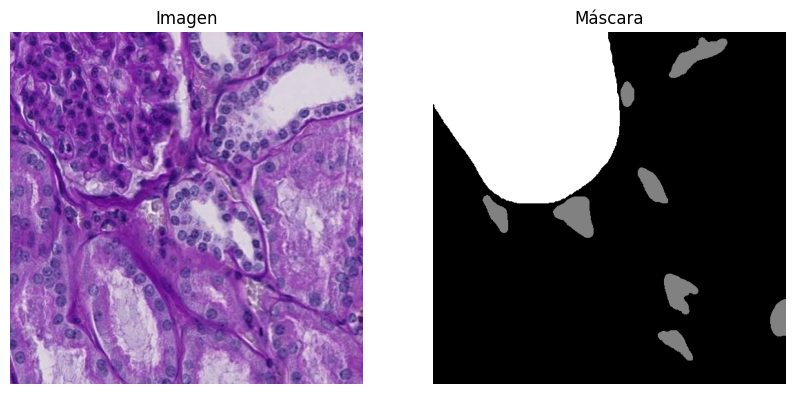

In [29]:
# Cargar y visualizar una imagen de prueba
idx = 0  # Índice de la imagen a visualizar
image_path = os.path.join(image_dir, image_files[idx])
mask_path = os.path.join(mask_dir, mask_files[idx])

image, mask = cargar_imagenes_y_mascaras(image_path, mask_path)

# Mostrar la imagen y su máscara
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title("Imagen")
ax[0].axis("off")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Máscara")
ax[1].axis("off")
plt.show()

## Implementación de arquitecturas neuronales

# Seg Net

```{admonition} ¿Qué es SegNet?
SegNet es una red neuronal convolucional (CNN) diseñada para la segmentación semántica de imágenes, lo que significa que asigna una etiqueta a cada píxel de la imagen de entrada. Se basa en un autoencoder convolucional con una arquitectura encoder-decoder.
```

#### Arquitectura de SegNet

- **Encoder**: Basado en VGG16, extrae características con capas convolucionales y de pooling.

- **Decoder**: Reconstruye la imagen de segmentación utilizando unpooling en lugar de upsampling tradicional, lo que mejora la preservación de bordes y detalles finos.

- **Softmax**: Produce un mapa de segmentación con probabilidades para cada clase.

## Seg Net

In [47]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3  # fondo + 3 clases
BATCH_SIZE = 1
NUM_IMAGES = 100

data_path1 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\train_filter"
data_path2 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\mascaras_guardadas"
IMAGE_DIR = os.path.join(data_path1, 'train_filter')
MASK_DIR = os.path.join(data_path2, 'mascaras_guardadas')

In [48]:
# ==== FUNCIONES ==== 
def fill_mask(mask):
    COLOR_MAPPING = {
        0: (1, 0, 0),
        1: (0, 1, 0),
        2: (0, 0, 1),
        3: (1, 0, 0)
    }
    color_mask = np.zeros(IMG_SIZE + (NUM_CLASSES,), dtype=np.uint8)
    for value, color in COLOR_MAPPING.items():
        color_mask[mask[:,:] == value] = color
    return color_mask

def load_image_mask_pair(name):
    img_path = os.path.join(IMAGE_DIR, f"{name}.tif")
    mask_path = os.path.join(MASK_DIR, f"{name}_mascara.tif")
    
    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        raise FileNotFoundError(f"No se encontró la imagen o máscara: {name}")
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)
    
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    
    mask_class = np.zeros(mask.shape[:2], dtype=np.uint8)
    mask_class[np.all(mask == [0, 0, 0], axis=-1)] = 0
    mask_class[np.all(mask == [255, 0, 0], axis=-1)] = 1
    mask_class[np.all(mask == [0, 255, 0], axis=-1)] = 2
    mask_class[np.all(mask == [0, 0, 255], axis=-1)] = 3
    mask_class = fill_mask(mask_class)
    
    return image / 255.0, mask_class

# ==== GENERADOR DE DATOS ==== 
class ImageMaskGenerator(Sequence):
    def __init__(self, image_filenames, batch_size=1):
        self.image_filenames = image_filenames
        self.batch_size = batch_size

    def __len__(self):
        return len(self.image_filenames) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.image_filenames[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for name in batch_files:
            try:
                img, mask = load_image_mask_pair(name)
                X.append(img)
                y.append(mask)
            except Exception as e:
                print(f"Error con {name}: {e}")
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [49]:
# Limitar imágenes
image_filenames = sorted([f.split('.')[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')])[:NUM_IMAGES]
train_filenames, val_filenames = train_test_split(image_filenames, test_size=0.2, random_state=42)
train_generator = ImageMaskGenerator(train_filenames, batch_size=BATCH_SIZE)
val_generator = ImageMaskGenerator(val_filenames, batch_size=BATCH_SIZE)

In [50]:
# MODELO SEGNET 
def build_segnet(input_shape, num_classes):
    inputs = layers.Input(input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    def encoder_block(x, filters):
        f = conv_block(x, filters)
        p = layers.MaxPooling2D((2, 2))(f)
        return f, p

    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    f1, p1 = encoder_block(inputs, 64)
    f2, p2 = encoder_block(p1, 128)
    f3, p3 = encoder_block(p2, 256)
    f4, p4 = encoder_block(p3, 512)
    b = conv_block(p4, 512)
    d4 = decoder_block(b, f4, 512)
    d3 = decoder_block(d4, f3, 256)
    d2 = decoder_block(d3, f2, 128)
    d1 = decoder_block(d2, f1, 64)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d1)
    model = models.Model(inputs, outputs)
    return model

# ==== MODELO SEGNET ==== 
model = build_segnet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[OneHotIoU(num_classes=3, target_class_ids=[0,1,2])])
model.summary()

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_14 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_105 (Conv2D)            (None, 128, 128, 64  1792        ['input_14[0][0]']               
                                )                                                                 
                                                                                                  
 batch_normalization_70 (BatchN  (None, 128, 128, 64  256        ['conv2d_105[0][0]']             
 ormalization)                  )                                                          

In [ ]:
# MODELO SEGNET 
def build_segnet(input_shape, num_classes):
    inputs = layers.Input(input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    def encoder_block(x, filters):
        f = conv_block(x, filters)
        p = layers.MaxPooling2D((2, 2))(f)
        return f, p

    def decoder_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
        return x

    f1, p1 = encoder_block(inputs, 64)
    f2, p2 = encoder_block(p1, 128)
    f3, p3 = encoder_block(p2, 256)
    f4, p4 = encoder_block(p3, 512)
    b = conv_block(p4, 512)
    d4 = decoder_block(b, f4, 512)
    d3 = decoder_block(d4, f3, 256)
    d2 = decoder_block(d3, f2, 128)
    d1 = decoder_block(d2, f1, 64)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(d1)
    model = models.Model(inputs, outputs)
    return model

# ==== MODELO SEGNET ==== 
model = build_segnet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[OneHotIoU(num_classes=3, target_class_ids=[0,1,2])])
model.summary()

Epoch 1/120
80/80 [==============================] - 14s 81ms/step - loss: 0.5630 - one_hot_io_u_4: 0.3041 - val_loss: 0.4969 - val_one_hot_io_u_4: 0.2888
Epoch 2/120
80/80 [==============================] - 5s 62ms/step - loss: 0.3465 - one_hot_io_u_4: 0.3178 - val_loss: 0.7414 - val_one_hot_io_u_4: 0.2888
Epoch 3/120
80/80 [==============================] - 5s 60ms/step - loss: 0.3341 - one_hot_io_u_4: 0.3151 - val_loss: 0.8383 - val_one_hot_io_u_4: 0.2888
Epoch 4/120
80/80 [==============================] - 4s 50ms/step - loss: 0.3164 - one_hot_io_u_4: 0.3253 - val_loss: 1.0268 - val_one_hot_io_u_4: 0.2888
Epoch 5/120
80/80 [==============================] - 4s 51ms/step - loss: 0.3134 - one_hot_io_u_4: 0.3178 - val_loss: 0.9615 - val_one_hot_io_u_4: 0.2888
Epoch 6/120
80/80 [==============================] - 4s 46ms/step - loss: 0.2985 - one_hot_io_u_4: 0.3389 - val_loss: 0.8488 - val_one_hot_io_u_4: 0.2888
Epoch 7/120
80/80 [==============================] - 4s 49ms/step - loss: 0

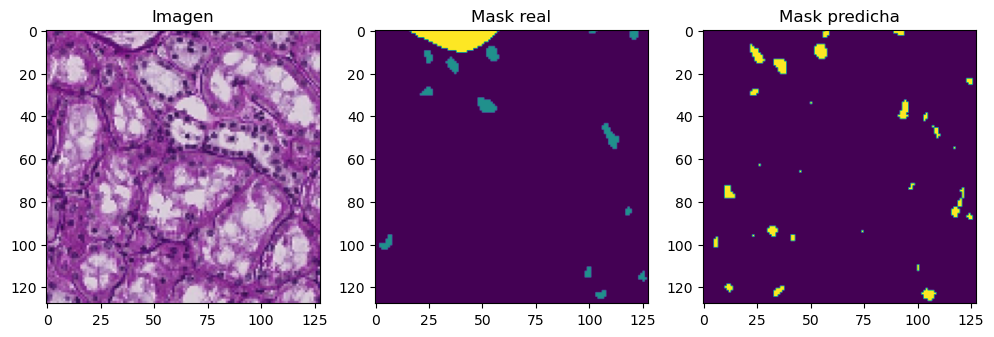

In [51]:
# ==== ENTRENAMIENTO CON EARLY STOPPING (paciencia 6) ==== 
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(train_generator, validation_data=val_generator, epochs=120, callbacks=[early_stopping])

# ==== EVALUACIÓN VISUAL ==== 
def show_sample_prediction():
    idx = np.random.randint(0, len(val_filenames))
    sample_name = val_filenames[idx]
    sample, true_mask = load_image_mask_pair(sample_name)
    pred = model.predict(sample[np.newaxis, ...])[0]
    pred_mask = np.argmax(pred, axis=-1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(sample)
    plt.title("Imagen")
    plt.subplot(1, 3, 2)
    plt.imshow(np.argmax(true_mask, axis=-1))
    plt.title("Mask real")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask)
    plt.title("Mask predicha")
    plt.show()

show_sample_prediction()

1/1 [==============================] - 0s 62ms/step


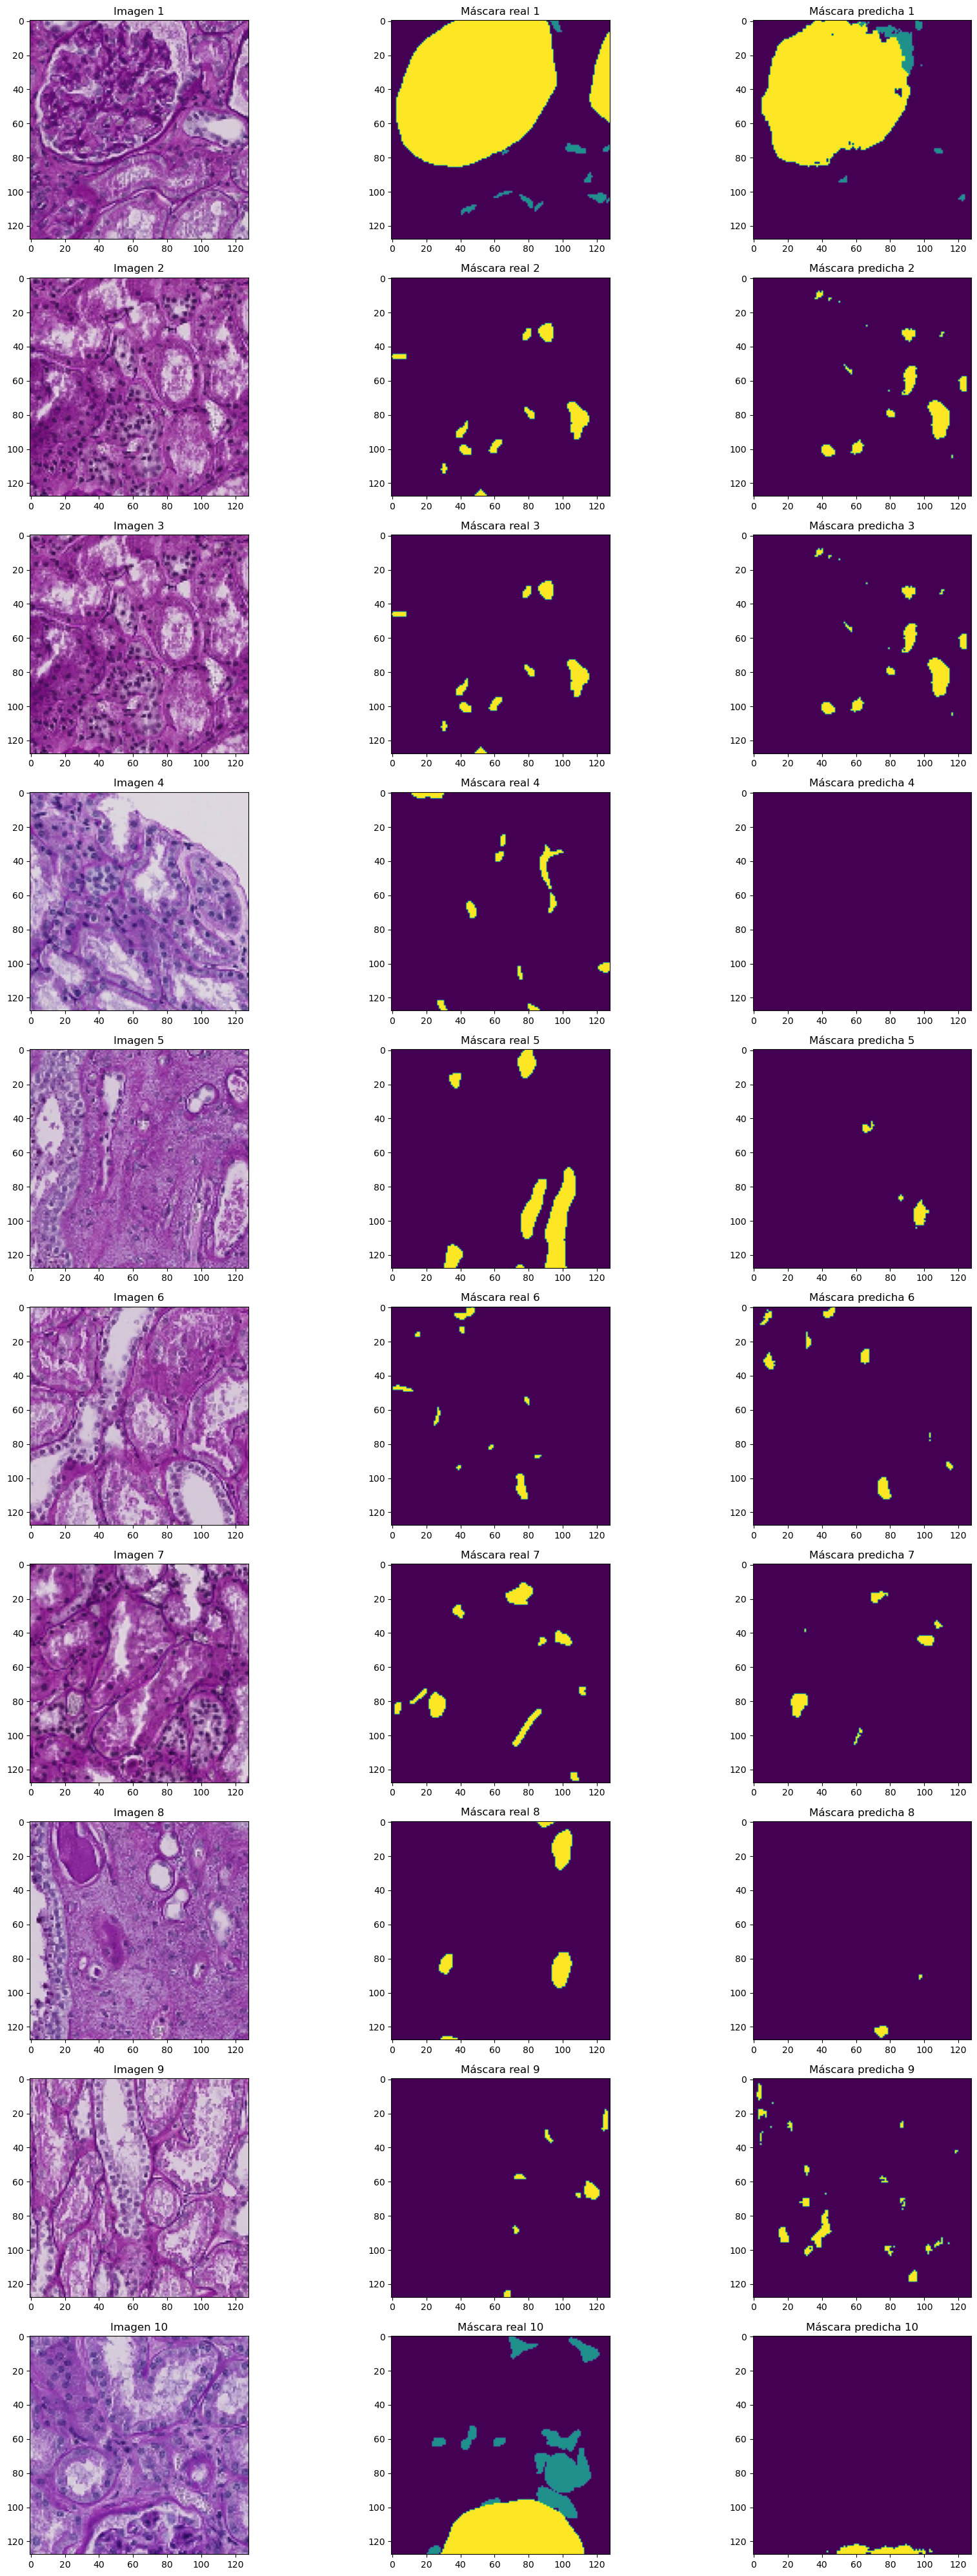

In [8]:
def show_multiple_predictions(num_samples=10):
    plt.figure(figsize=(18, num_samples * 4))  # Tamaño de la figura
    for i in range(num_samples):
        idx = np.random.randint(0, len(val_filenames))
        sample_name = val_filenames[idx]
        sample, true_mask = load_image_mask_pair(sample_name)
        pred = model.predict(sample[np.newaxis, ...])[0]
        pred_mask = np.argmax(pred, axis=-1)

        # Subgráfico 1: Imagen
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(sample)
        plt.title(f"Imagen {i+1}")

        # Subgráfico 2: Máscara real
        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(np.argmax(true_mask, axis=-1))
        plt.title(f"Máscara real {i+1}")

        # Subgráfico 3: Máscara predicha
        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask)
        plt.title(f"Máscara predicha {i+1}")
    plt.tight_layout()
    plt.show()

# Llamada a la función para mostrar 10 imágenes, máscaras y predicciones
show_multiple_predictions(num_samples=10)


📊 Resumen de Métricas  

- **Pérdida en entrenamiento (`loss`)**: 0.0157  
- **IoU en entrenamiento (`IoU`)**: 0.9535  
- **Pérdida en validación (`val_loss`)**: 0.8728  
- **IoU en validación (`val_IoU`)**: 0.3749  

🧠 Interpretación:  

El modelo muestra un **IoU del 95.3% en entrenamiento**, lo que indica que ha aprendido muy bien a segmentar las imágenes de entrenamiento. Sin embargo, el **IoU en validación es de solo 37.5%**, lo que sugiere un fuerte sobreajuste. La diferencia entre ambas métricas es significativa, lo que indica que el modelo está memorizando los datos de entrenamiento en lugar de aprender patrones generales aplicables a nuevas imágenes. La **pérdida en entrenamiento (`loss`)** es extremadamente baja (**0.0157**), lo que refuerza la idea de que el modelo ha ajustado demasiado bien los datos de entrenamiento. Sin embargo, la **pérdida en validación (`val_loss`)** es considerablemente mayor (**0.8728**), lo que confirma la brecha en el rendimiento entre ambos conjuntos.  


In [52]:
history.history.keys()

dict_keys(['loss', 'one_hot_io_u_4', 'val_loss', 'val_one_hot_io_u_4'])

In [53]:
# Extraer los últimos valores de cada métrica
train_loss = history.history['loss'][-1]
train_iou = history.history['one_hot_io_u_4'][-1]
val_loss = history.history['val_loss'][-1]
val_iou = history.history['val_one_hot_io_u_4'][-1]

# Crear la tabla de resultados
table = [
    ["Métrica", "Valor Final"],
    ["Pérdida entrenamiento (loss)", f"{train_loss:.4f}"],
    ["IoU entrenamiento", f"{train_iou:.4f}"],
    ["Pérdida validación (val_loss)", f"{val_loss:.4f}"],
    ["IoU validación", f"{val_iou:.4f}"]
]

print("RESUMEN DE MÉTRICAS DEL MODELO")
print(tabulate(table, headers="firstrow", tablefmt="grid"))

RESUMEN DE MÉTRICAS DEL MODELO
+-------------------------------+---------------+
| Métrica                       |   Valor Final |
+===============================+===============+
| Pérdida entrenamiento (loss)  |        0.0157 |
+-------------------------------+---------------+
| IoU entrenamiento             |        0.9535 |
+-------------------------------+---------------+
| Pérdida validación (val_loss) |        0.8728 |
+-------------------------------+---------------+
| IoU validación                |        0.3749 |
+-------------------------------+---------------+


## PSP Net

```{admonition} ¿Qué es PSPNet (Pyramid Scene Parsing Network)?
PSPNet (Pyramid Scene Parsing Network) es una arquitectura de redes neuronales profundas diseñada para la **segmentación semántica de imágenes**. Fue propuesta por **Zhao et al. en 2017** y destaca por su capacidad de capturar información global de la imagen utilizando un **módulo de pirámide de pooling**.

```

***¿Cómo funciona PSPNet?***

PSPNet introduce una estrategia innovadora llamada **Pyramid Pooling Module (PPM)**, la cual permite capturar información a diferentes escalas. Su estructura principal consta de las siguientes etapas:

1. **Backbone (Red Base):** PSPNet utiliza una red preentrenada como **ResNet-50 o ResNet-101** como extractor de características.
2. **Pyramid Pooling Module (PPM):** 
   - Extrae información de la imagen a **múltiples escalas** mediante pooling adaptativo.
   - Genera mapas de características a partir de **cuatro niveles de pooling** con tamaños de ventanas diferentes (1x1, 2x2, 3x3, 6x6).
   - Concatenación de los mapas obtenidos con la salida del backbone.
3. **Clasificación y Upsampling:**
   - Se combinan las características obtenidas con las originales.
   - Se aplica **una capa de convolución** y se realiza un **upsampling** para recuperar la resolución original de la imagen.

***Arquitectura de PSPNet***

```plaintext
Entrada → ResNet (Backbone) → Pyramid Pooling Module (PPM) → Convoluciones → Upsampling → Salida
```


In [ ]:
IMG_SIZE = (128, 128)
NUM_CLASSES = 3  # fondo + 3 clases
BATCH_SIZE = 1
NUM_IMAGES = 200  # Limitar a 200 imágenes

data_path1 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\train_filter"
data_path2 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\mascaras_guardadas"
IMAGE_DIR = os.path.join(data_path1, 'train_filter')
MASK_DIR = os.path.join(data_path2, 'mascaras_guardadas')

In [ ]:
# ==== FUNCIONES ==== 
def fill_mask(mask):
    COLOR_MAPPING = {
        0: (1, 0, 0),
        1: (0, 1, 0),
        2: (0, 0, 1),
        3: (1, 0, 0)
    }
    color_mask = np.zeros(IMG_SIZE + (NUM_CLASSES,), dtype=np.uint8)
    for value, color in COLOR_MAPPING.items():
        color_mask[mask[:,:] == value] = color
    return color_mask

def load_image_mask_pair(name):
    img_path = os.path.join(IMAGE_DIR, f"{name}.tif")
    mask_path = os.path.join(MASK_DIR, f"{name}_mascara.tif")
    
    if not os.path.exists(img_path) or not os.path.exists(mask_path):
        raise FileNotFoundError(f"No se encontró la imagen o máscara: {name}")
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)
    
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    
    mask_class = np.zeros(mask.shape[:2], dtype=np.uint8)
    mask_class[np.all(mask == [0, 0, 0], axis=-1)] = 0
    mask_class[np.all(mask == [255, 0, 0], axis=-1)] = 1
    mask_class[np.all(mask == [0, 255, 0], axis=-1)] = 2
    mask_class[np.all(mask == [0, 0, 255], axis=-1)] = 3
    mask_class = fill_mask(mask_class)
    
    return image / 255.0, mask_class

# ==== GENERADOR DE DATOS ==== 
class ImageMaskGenerator(Sequence):
    def __init__(self, image_filenames, batch_size=1):
        self.image_filenames = image_filenames
        self.batch_size = batch_size

    def __len__(self):
        return len(self.image_filenames) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.image_filenames[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for name in batch_files:
            try:
                img, mask = load_image_mask_pair(name)
                X.append(img)
                y.append(mask)
            except Exception as e:
                print(f"Error con {name}: {e}")
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [ ]:
# Limitar imágenes
image_filenames = sorted([f.split('.')[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')])[:NUM_IMAGES]
train_filenames, val_filenames = train_test_split(image_filenames, test_size=0.2, random_state=42)
train_generator = ImageMaskGenerator(train_filenames, batch_size=BATCH_SIZE)
val_generator = ImageMaskGenerator(val_filenames, batch_size=BATCH_SIZE)

In [ ]:
# ==== MODELO PSPNet ==== 
def build_pspnet(input_shape, num_classes):
    inputs = layers.Input(input_shape)
    
    # Encoder (ResNet-like backbone)
    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Pooling layers with different scales (Pyramid Pooling Module)
    pool1 = layers.AveragePooling2D(pool_size=(1, 1))(x)
    pool1 = layers.Conv2D(32, 1, padding='same')(pool1)
    pool1 = layers.BatchNormalization()(pool1)
    pool1 = layers.Activation('relu')(pool1)
    pool1 = layers.UpSampling2D(size=(1, 1), interpolation='bilinear')(pool1)
    
    pool2 = layers.AveragePooling2D(pool_size=(2, 2))(x)
    pool2 = layers.Conv2D(32, 1, padding='same')(pool2)
    pool2 = layers.BatchNormalization()(pool2)
    pool2 = layers.Activation('relu')(pool2)
    pool2 = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(pool2)
    
    pool3 = layers.AveragePooling2D(pool_size=(4, 4))(x)
    pool3 = layers.Conv2D(32, 1, padding='same')(pool3)
    pool3 = layers.BatchNormalization()(pool3)
    pool3 = layers.Activation('relu')(pool3)
    pool3 = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(pool3)
    
    pool4 = layers.AveragePooling2D(pool_size=(8, 8))(x)
    pool4 = layers.Conv2D(32, 1, padding='same')(pool4)
    pool4 = layers.BatchNormalization()(pool4)
    pool4 = layers.Activation('relu')(pool4)
    pool4 = layers.UpSampling2D(size=(8, 8), interpolation='bilinear')(pool4)
    
    # Concatenate all pyramid levels
    x = layers.Concatenate()([x, pool1, pool2, pool3, pool4])
    
    # Final convolution
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Output
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model

# ==== MODELO PSPNet ==== 
model = build_pspnet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[OneHotIoU(num_classes=3, target_class_ids=[0,1,2])])
model.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_68 (Conv2D)             (None, 128, 128, 64  1792        ['input_11[0][0]']               
                                )                                                                 
                                                                                                  
 batch_normalization_36 (BatchN  (None, 128, 128, 64  256        ['conv2d_68[0][0]']              
 ormalization)                  )                                                           

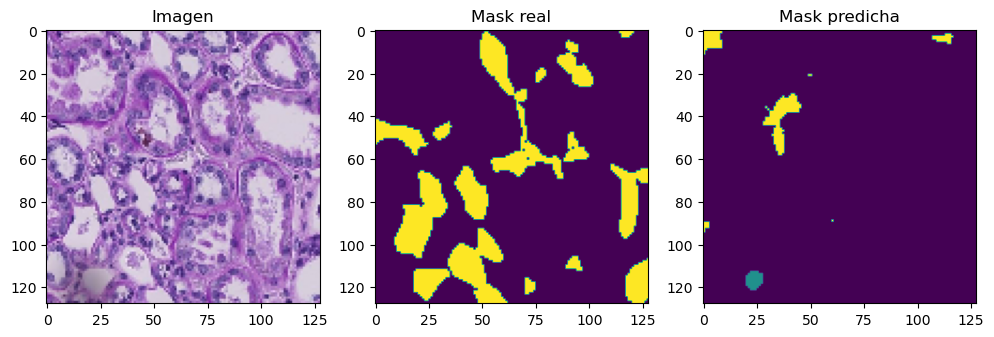

In [ ]:
# ==== ENTRENAMIENTO CON EARLY STOPPING (paciencia 6) ==== 
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(train_generator, validation_data=val_generator, epochs=120, callbacks=[early_stopping])

# ==== EVALUACIÓN VISUAL ==== 
def show_sample_prediction():
    idx = np.random.randint(0, len(val_filenames))
    sample_name = val_filenames[idx]
    sample, true_mask = load_image_mask_pair(sample_name)
    pred = model.predict(sample[np.newaxis, ...])[0]
    pred_mask = np.argmax(pred, axis=-1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(sample)
    plt.title("Imagen")
    plt.subplot(1, 3, 2)
    plt.imshow(np.argmax(true_mask, axis=-1))
    plt.title("Mask real")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask)
    plt.title("Mask predicha")
    plt.show()

show_sample_prediction()

1/1 [==============================] - 0s 87ms/step


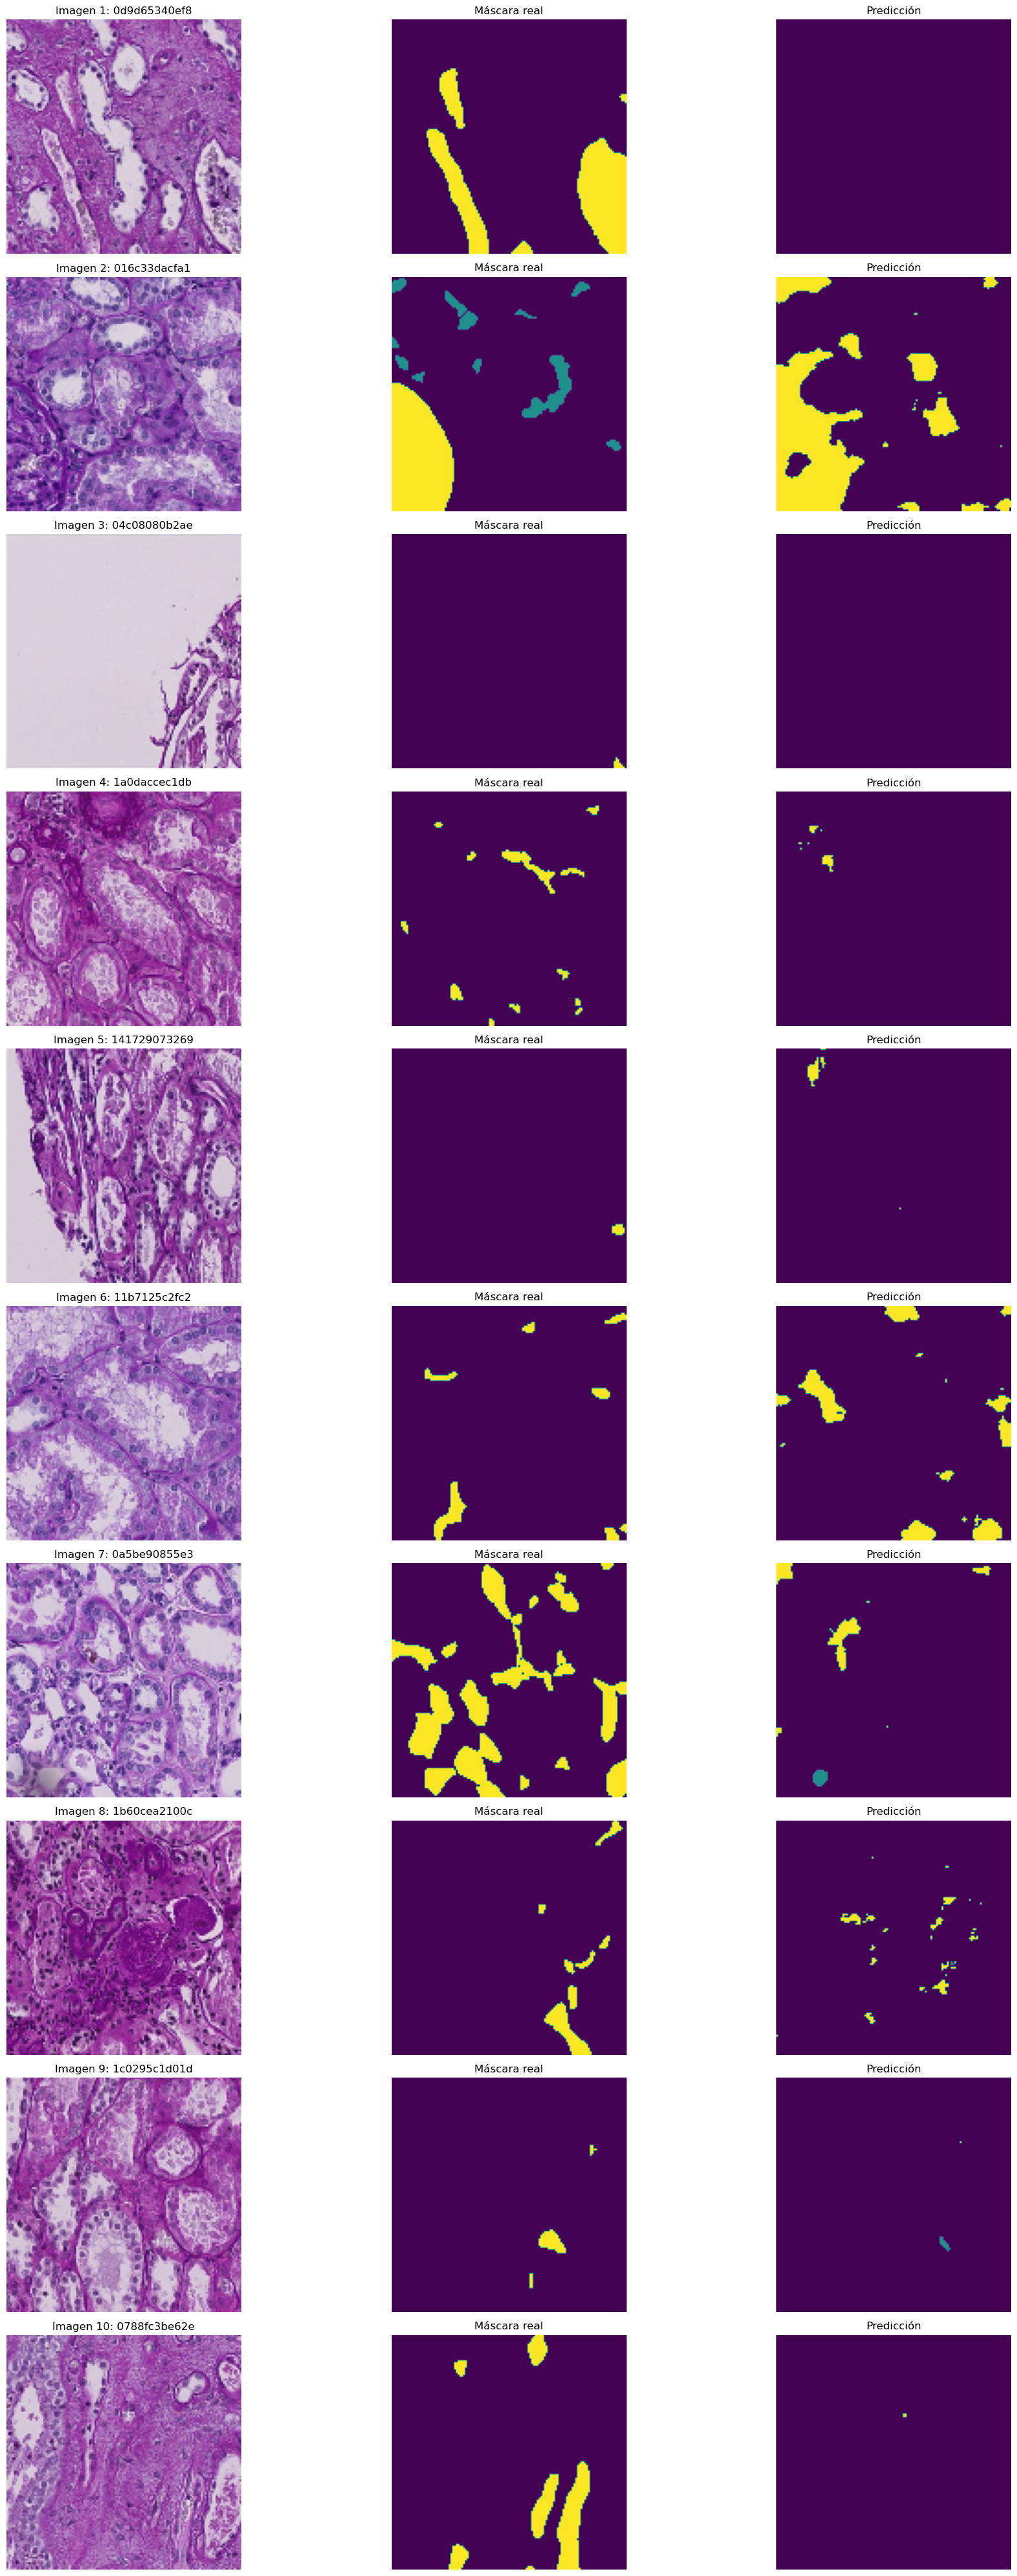

In [29]:
def visualize_predictions(num_samples=10):
    plt.figure(figsize=(20, 4*num_samples))
    
    for i in range(num_samples):
        if i >= len(val_filenames):
            break
            
        sample_name = val_filenames[i]
        sample, true_mask = load_image_mask_pair(sample_name)
        pred = model.predict(sample[np.newaxis, ...])[0]
        pred_mask = np.argmax(pred, axis=-1)
        true_mask_class = np.argmax(true_mask, axis=-1)
        
        # Imagen original
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(sample)
        plt.title(f"Imagen {i+1}: {sample_name}")
        plt.axis('off')
        
        # Máscara real
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(true_mask_class)
        plt.title("Máscara real")
        plt.axis('off')
        
        # Predicción
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_mask)
        plt.title("Predicción")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizar las primeras 10 imágenes
visualize_predictions(10)

📊 Resultados del Modelo PSPNet  

- **Pérdida en entrenamiento (`loss`)**: 0.1308  
- **IoU en entrenamiento (`IoU`)**: 0.6872  
- **Pérdida en validación (`val_loss`)**: 1.423  
- **IoU en validación (`val_IoU`)**: 0.2259  

🧠 Interpretación:  

El modelo PSPNet muestra un **IoU del 68.7% en entrenamiento**, lo que indica que ha aprendido correctamente la segmentación en los datos de entrenamiento. Sin embargo, el **IoU en validación es de solo 22.6%**, acompañado de una pérdida significativamente mayor en validación que en entrenamiento. Esto sugiere que el modelo puede estar sobreajustado, aprendiendo patrones específicos de los datos de entrenamiento sin generalizar bien a los datos nuevos. La **pérdida en entrenamiento (`loss`)** es de **0.1308**, lo que indica que el modelo logra minimizar el error en los datos de entrenamiento. No obstante, la **pérdida en validación (`val_loss`)** es significativamente mayor (**1.423**), lo que sugiere un problema de sobreajuste. En otras palabras, el modelo está aprendiendo demasiado bien los patrones específicos del conjunto de entrenamiento, pero no está logrando aplicar ese conocimiento de manera efectiva en datos no vistos.  



In [ ]:
from tabulate import tabulate

# Extraer los últimos valores de cada métrica
train_loss = history.history['loss'][-1]
train_iou = history.history['one_hot_io_u_2'][-1]
val_loss = history.history['val_loss'][-1]
val_iou = history.history['val_one_hot_io_u_2'][-1]

# Crear la tabla de resultados
table = [
    ["Métrica", "Valor Final"],
    ["Pérdida entrenamiento (loss)", f"{train_loss:.4f}"],
    ["IoU entrenamiento", f"{train_iou:.4f}"],
    ["Pérdida validación (val_loss)", f"{val_loss:.4f}"],
    ["IoU validación", f"{val_iou:.4f}"]
]

print("RESUMEN DE MÉTRICAS DEL MODELO")
print(tabulate(table, headers="firstrow", tablefmt="grid"))


RESUMEN DE MÉTRICAS DEL MODELO
+-------------------------------+---------------+
| Métrica                       |   Valor Final |
+===============================+===============+
| Pérdida entrenamiento (loss)  |        0.1308 |
+-------------------------------+---------------+
| IoU entrenamiento             |        0.6872 |
+-------------------------------+---------------+
| Pérdida validación (val_loss) |        1.423  |
+-------------------------------+---------------+
| IoU validación                |        0.2259 |
+-------------------------------+---------------+


## V Net

![Descripción de la aequitectura VNET](Arquitecturas/vnet.png)

📊 Resultados del Modelo V-Net  

- **Pérdida en entrenamiento (`loss`)**: 0.0399  
- **IoU en entrenamiento (`IoU`)**: 0.284  
- **Pérdida en validación (`val_loss`)**: 0.3334  
- **IoU en validación (`val_IoU`)**: 0.3333  

🧠 Interpretación:  

El modelo V-Net muestra un **IoU del 28.4% en entrenamiento**, lo que indica que su capacidad de segmentación en los datos de entrenamiento es baja en comparación con otros modelos. Sin embargo, el **IoU en validación es de 33.3%**, lo que es inusual, ya que el rendimiento en validación suele ser peor que en entrenamiento. La **pérdida en entrenamiento (`loss`)** es **0.0399**, lo que indica que el modelo logra minimizar su error en los datos de entrenamiento. No obstante, la **pérdida en validación (`val_loss`)** es **0.3334**, significativamente mayor que la de entrenamiento.

In [ ]:
# ===== CONFIGURACIÓN =====
IMG_SIZE = (128, 128)
NUM_CLASSES = 3  # fondo + 2 clases (según tu mapeo original)
BATCH_SIZE = 4    # Aumentado para V-Net
NUM_IMAGES = 200

# ===== PREPARACIÓN DE DATOS (Manteniendo tu código original) =====
data_path1 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\train_filter"
data_path2 = r"C:\Users\henry\Documents\jbook\parcial1_dl\datos\mascaras_guardadas"
IMAGE_DIR = os.path.join(data_path1, 'train_filter')
MASK_DIR = os.path.join(data_path2, 'mascaras_guardadas')

In [ ]:
def fill_mask(mask):
    COLOR_MAPPING = {
        0: (1, 0, 0),
        1: (0, 1, 0),
        2: (0, 0, 1),
        3: (1, 0, 0)
    }
    color_mask = np.zeros(IMG_SIZE + (NUM_CLASSES,), dtype=np.uint8)
    for value, color in COLOR_MAPPING.items():
        color_mask[mask[:,:] == value] = color
    return color_mask

def load_image_mask_pair(name):
    img_path = os.path.join(IMAGE_DIR, f"{name}.tif")
    mask_path = os.path.join(MASK_DIR, f"{name}_mascara.tif")
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)
    
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    
    mask_class = np.zeros(mask.shape[:2], dtype=np.uint8)
    mask_class[np.all(mask == [0, 0, 0], axis=-1)] = 0
    mask_class[np.all(mask == [255, 0, 0], axis=-1)] = 1
    mask_class[np.all(mask == [0, 255, 0], axis=-1)] = 2
    mask_class[np.all(mask == [0, 0, 255], axis=-1)] = 3
    mask_class = fill_mask(mask_class)
    
    return image / 255.0, mask_class

class ImageMaskGenerator(Sequence):
    def __init__(self, image_filenames, batch_size=4):
        self.image_filenames = image_filenames
        self.batch_size = batch_size

    def __len__(self):
        return len(self.image_filenames) // self.batch_size

    def __getitem__(self, idx):
        batch_files = self.image_filenames[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for name in batch_files:
            img, mask = load_image_mask_pair(name)
            X.append(img)
            y.append(mask)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [ ]:
# ===== ARQUITECTURA V-NET =====
def conv_block(x, filters, kernel_size=3, activation='relu'):
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def downsample_block(x, filters):
    # Camino contractivo
    x = conv_block(x, filters)
    x = conv_block(x, filters)
    skip = x  # Conexión residual
    x = layers.MaxPooling2D((2, 2))(x)
    return x, skip

def upsample_block(x, skip, filters):
    # Camino expansivo
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])  # Conexión residual
    x = conv_block(x, filters)
    x = conv_block(x, filters)
    return x

def build_vnet(input_shape, num_classes):
    inputs = layers.Input(input_shape)
    
    # Encoder (Downsampling)
    x1, skip1 = downsample_block(inputs, 32)  # 128x128 -> 64x64
    x2, skip2 = downsample_block(x1, 64)     # 64x64 -> 32x32
    x3, skip3 = downsample_block(x2, 128)     # 32x32 -> 16x16
    x4, skip4 = downsample_block(x3, 256)     # 16x16 -> 8x8
    
    # Bottleneck
    x5 = conv_block(x4, 512)
    x5 = conv_block(x5, 512)
    
    # Decoder (Upsampling)
    x6 = upsample_block(x5, skip4, 256)       # 8x8 -> 16x16
    x7 = upsample_block(x6, skip3, 128)       # 16x16 -> 32x32
    x8 = upsample_block(x7, skip2, 64)        # 32x32 -> 64x64
    x9 = upsample_block(x8, skip1, 32)        # 64x64 -> 128x128
    
    # Output
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x9)
    
    model = models.Model(inputs, outputs)
    return model

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_76 (Conv2D)             (None, 128, 128, 32  896         ['input_12[0][0]']               
                                )                                                                 
                                                                                                  
 batch_normalization_43 (BatchN  (None, 128, 128, 32  128        ['conv2d_76[0][0]']              
 ormalization)                  )                                                           

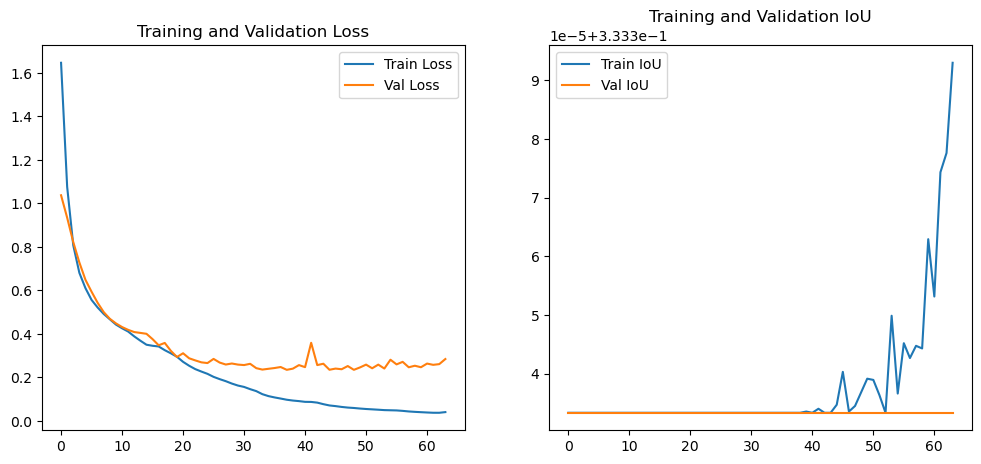

1/1 [==============================] - 1s 729ms/step


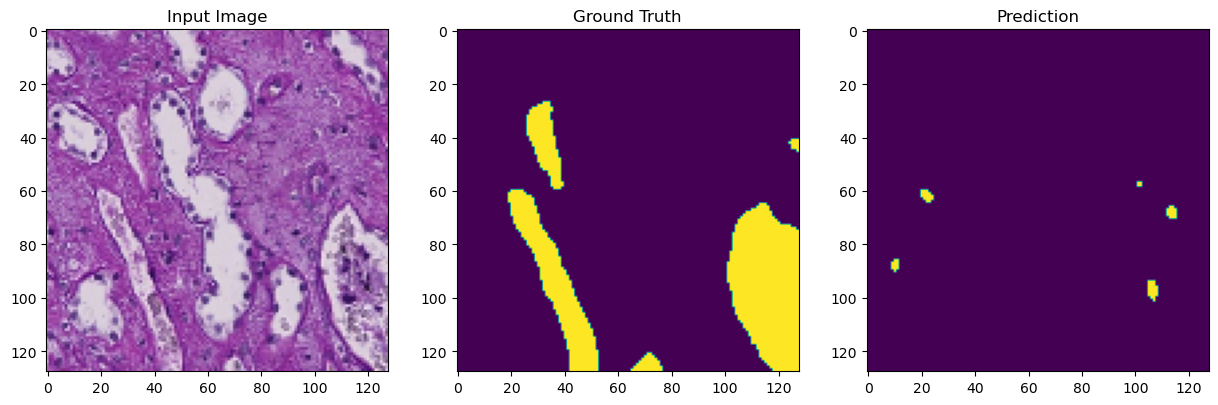

In [ ]:
# ===== ENTRENAMIENTO =====
# Preparar datos
image_filenames = sorted([f.split('.')[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.tif')])[:NUM_IMAGES]
train_filenames, val_filenames = train_test_split(image_filenames, test_size=0.2, random_state=42)
train_generator = ImageMaskGenerator(train_filenames, batch_size=BATCH_SIZE)
val_generator = ImageMaskGenerator(val_filenames, batch_size=BATCH_SIZE)

# Construir y compilar V-Net
model = build_vnet(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy', MeanIoU(num_classes=NUM_CLASSES, name='iou')])

model.summary()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Entrenamiento
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=100,
                    callbacks=[early_stopping])

# ===== EVALUACIÓN =====
def visualize_results():
    # Visualizar métricas
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['iou'], label='Train IoU')
    plt.plot(history.history['val_iou'], label='Val IoU')
    plt.title('Training and Validation IoU')
    plt.legend()
    plt.show()

    # Visualizar predicciones
    sample, true_mask = load_image_mask_pair(val_filenames[0])
    pred = model.predict(sample[np.newaxis, ...])[0]
    pred_mask = np.argmax(pred, axis=-1)
    true_mask_class = np.argmax(true_mask, axis=-1)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(sample)
    plt.title('Input Image')
    
    plt.subplot(1, 3, 2)
    plt.imshow(true_mask_class)
    plt.title('Ground Truth')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask)
    plt.title('Prediction')
    plt.show()

visualize_results()

In [43]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'iou', 'val_loss', 'val_accuracy', 'val_iou'])

In [45]:

# Extraer los últimos valores de cada métrica
train_loss = history.history['loss'][-1]
train_iou = history.history['val_loss'][-1]
val_loss = history.history['iou'][-1]
val_iou = history.history['val_iou'][-1]

# Crear la tabla de resultados
table = [
    ["Métrica", "Valor Final"],
    ["Pérdida entrenamiento (loss)", f"{train_loss:.4f}"],
    ["IoU entrenamiento", f"{train_iou:.4f}"],
    ["Pérdida validación (val_loss)", f"{val_loss:.4f}"],
    ["IoU validación", f"{val_iou:.4f}"]
]

print("RESUMEN DE MÉTRICAS DEL MODELO")
print(tabulate(table, headers="firstrow", tablefmt="grid"))

RESUMEN DE MÉTRICAS DEL MODELO
+-------------------------------+---------------+
| Métrica                       |   Valor Final |
+===============================+===============+
| Pérdida entrenamiento (loss)  |        0.0399 |
+-------------------------------+---------------+
| IoU entrenamiento             |        0.284  |
+-------------------------------+---------------+
| Pérdida validación (val_loss) |        0.3334 |
+-------------------------------+---------------+
| IoU validación                |        0.3333 |
+-------------------------------+---------------+


1/1 [==============================] - 0s 60ms/step


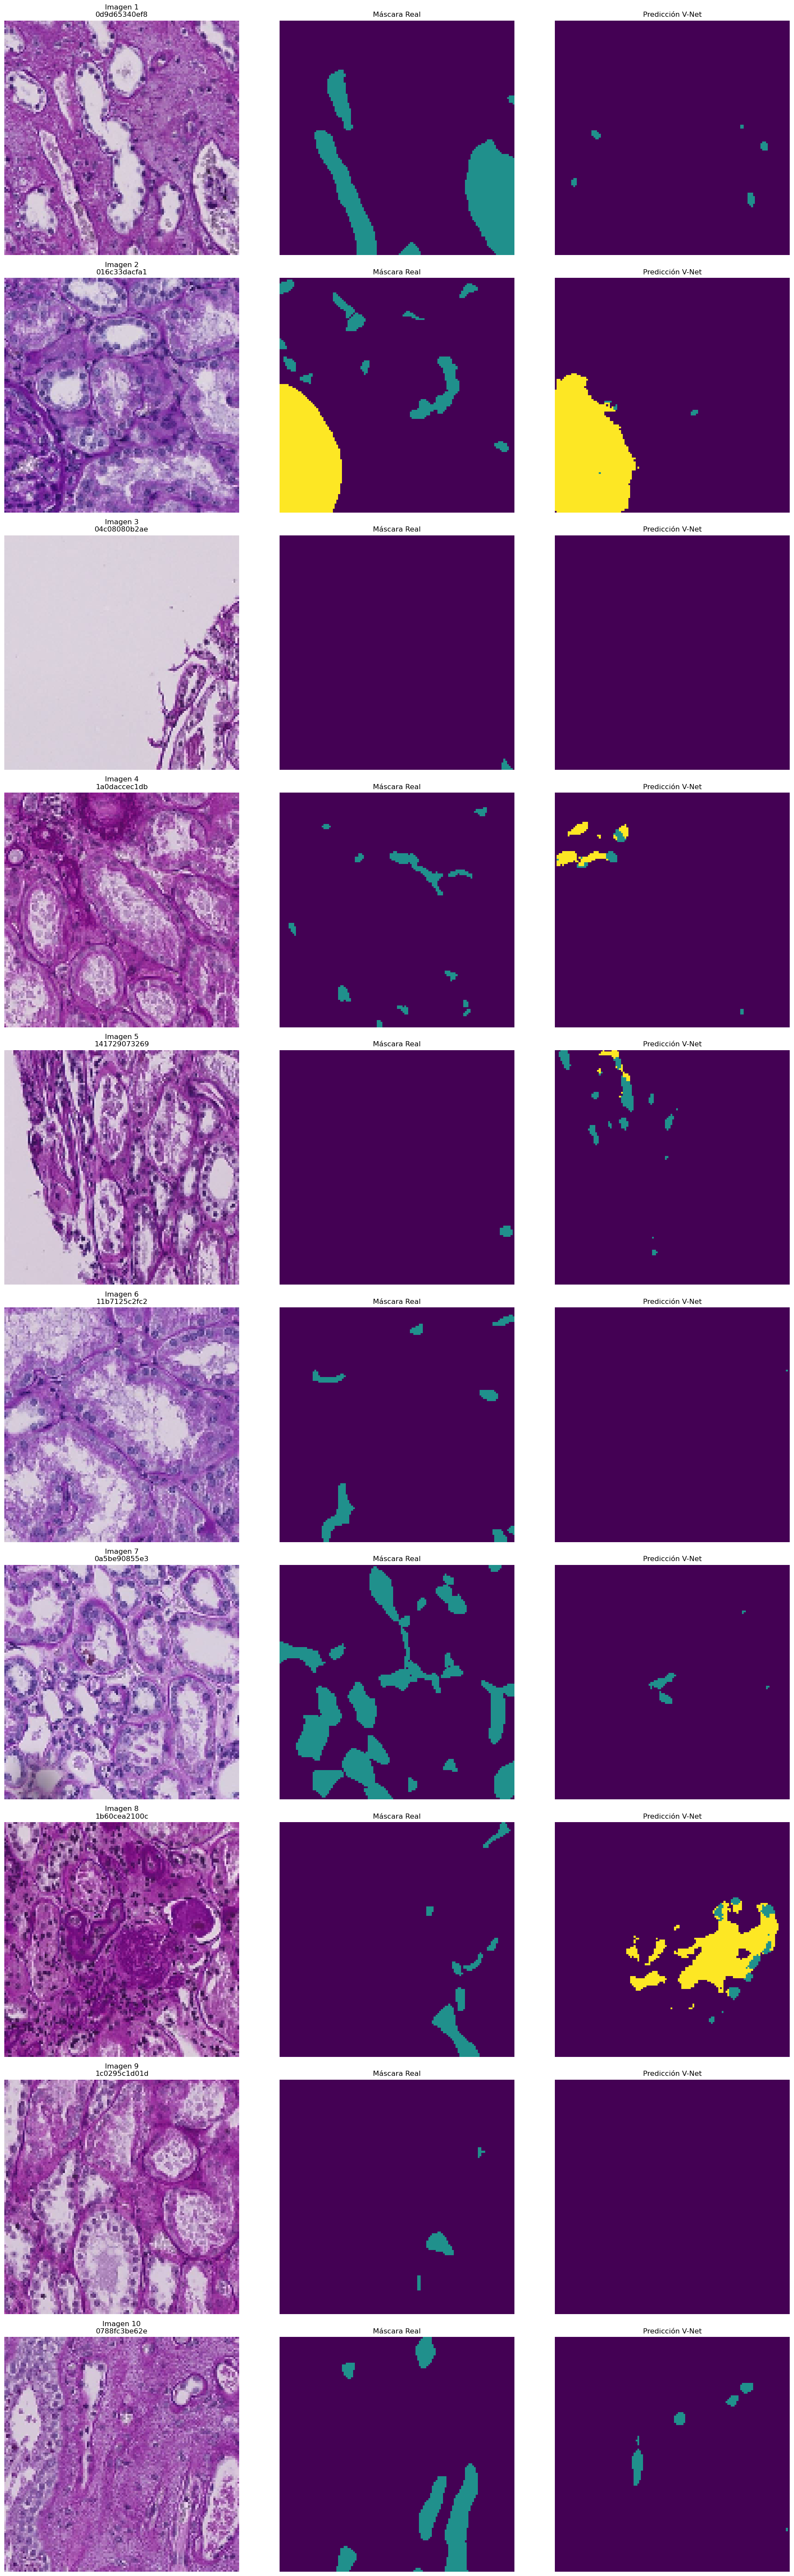

In [38]:
def visualize_first_10_predictions():
    plt.figure(figsize=(20, 6*10))  # Ajustar tamaño para 10 filas
    
    for i in range(10):
        if i >= len(val_filenames):
            break
            
        # Cargar datos
        sample_name = val_filenames[i]
        image, true_mask = load_image_mask_pair(sample_name)
        
        # Predecir
        pred_mask = model.predict(image[np.newaxis, ...])[0]
        pred_class = np.argmax(pred_mask, axis=-1)
        true_class = np.argmax(true_mask, axis=-1)
        
        # Visualizar imagen original
        plt.subplot(10, 3, i*3 + 1)
        plt.imshow(image)
        plt.title(f"Imagen {i+1}\n{sample_name}")
        plt.axis('off')
        
        # Visualizar máscara real
        plt.subplot(10, 3, i*3 + 2)
        plt.imshow(true_class, vmin=0, vmax=NUM_CLASSES-1)
        plt.title("Máscara Real")
        plt.axis('off')
        
        # Visualizar predicción
        plt.subplot(10, 3, i*3 + 3)
        plt.imshow(pred_class, vmin=0, vmax=NUM_CLASSES-1)
        plt.title("Predicción V-Net")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Llamar a la función
visualize_first_10_predictions()